# TCGA LUAD — Multi-Modal Survival Analysis
**Dataset:** TCGA Lung Adenocarcinoma, Pan-Cancer Atlas 2018 (cBioPortal)  
**N:** 505 patients (566 total, 61 excluded — missing OS)  
**Goal:** RWE analysis integrating clinical and molecular biomarker data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test, multivariate_logrank_test
from pathlib import Path

df = pd.read_csv("../data/processed/clinical_clean.csv")
df = df.dropna(subset=["OS_MONTHS"])
print("Working n:", len(df))
print("OS events:", df["OS_EVENT"].sum())

## 1. Overall Survival
Kaplan-Meier estimate for the full cohort. Median OS and confidence interval shown.

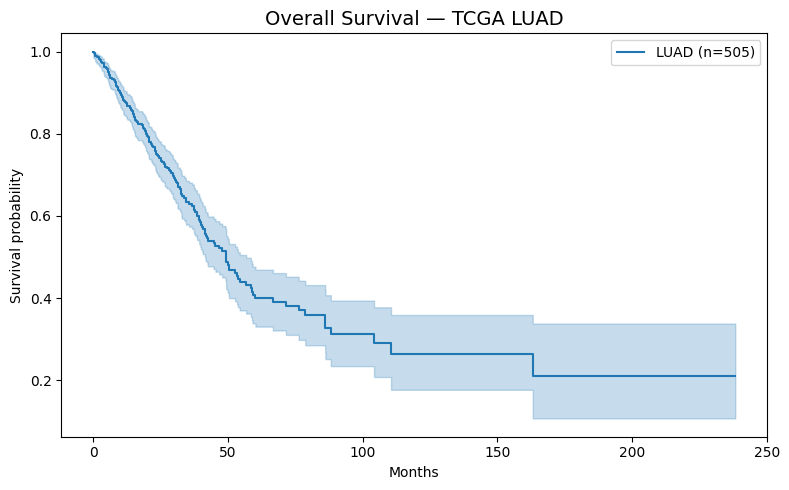

Median OS: 49.28165171


In [2]:
kmf = KaplanMeierFitter()
kmf.fit(df["OS_MONTHS"], df["OS_EVENT"], label="LUAD (n={})".format(len(df)))

fig, ax = plt.subplots(figsize=(8,5))
kmf.plot_survival_function(ax=ax, ci_show=True)
ax.set_title("Overall Survival — TCGA LUAD", fontsize=14)
ax.set_xlabel("Months")
ax.set_ylabel("Survival probability")
plt.tight_layout()
plt.savefig("figures/fig1_km_overall.png", dpi=150)
plt.show()
print("Median OS:", kmf.median_survival_time_)

## 2. Survival by Pathologic Stage
Stage is the primary clinical prognosticator in LUAD. We expect clear separation across stages, consistent with published literature.

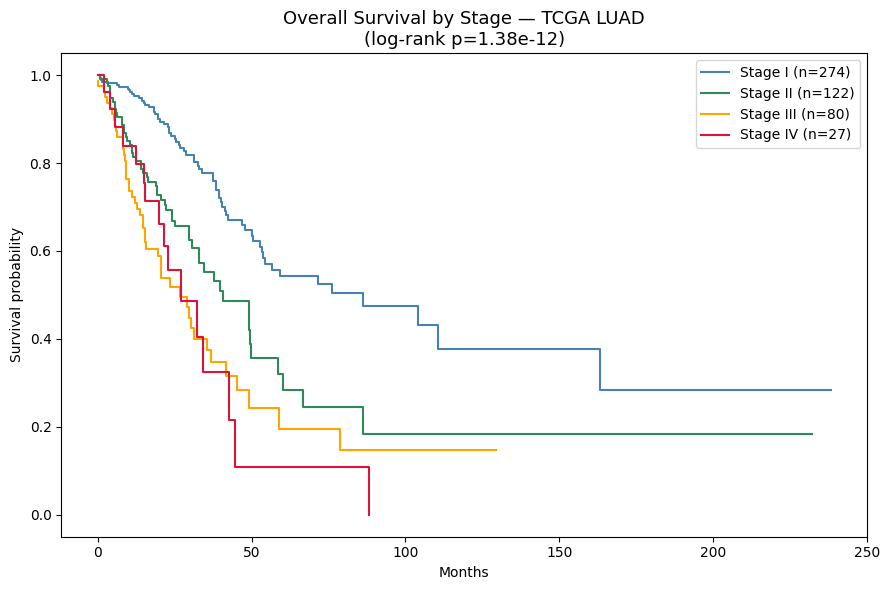

In [3]:
fig, ax = plt.subplots(figsize=(9,6))

colors = {"I": "steelblue", "II": "seagreen", "III": "orange", "IV": "crimson"}

for stage, group in df.groupby("STAGE_SIMPLE"):
    if pd.isna(stage):
        continue
    kmf = KaplanMeierFitter()
    kmf.fit(group["OS_MONTHS"], group["OS_EVENT"], 
            label=f"Stage {stage} (n={len(group)})")
    kmf.plot_survival_function(ax=ax, ci_show=False, color=colors.get(stage))

# Log-rank test
from lifelines.statistics import multivariate_logrank_test
df_stage = df.dropna(subset=["STAGE_SIMPLE"])
results = multivariate_logrank_test(df_stage["OS_MONTHS"], 
                                     df_stage["STAGE_SIMPLE"], 
                                     df_stage["OS_EVENT"])

ax.set_title(f"Overall Survival by Stage — TCGA LUAD\n(log-rank p={results.p_value:.2e})", fontsize=13)
ax.set_xlabel("Months")
ax.set_ylabel("Survival probability")
ax.legend()
plt.tight_layout()
plt.savefig("figures/fig2_km_stage.png", dpi=150)
plt.show()

Stage separation is highly significant (log-rank p=1.38e-12). Stage I patients show dramatically better long-term survival, with a plateau suggesting a subset of long-term survivors. Notably, Stage III and IV curves cross early (~10 months), which may reflect more aggressive treatment in Stage III patients — this will be explored in the treatment analysis section.

## 3. Survival by Molecular Subtype
TCGA LUAD includes molecularly-defined subtypes based on multi-omic profiling. Unlike purely clinical staging, molecular subtypes capture tumor biology and may provide prognostic value independent of stage.

In [4]:
print("Subtypes disponibles:\n", df["SUBTYPE"].value_counts())

Subtypes disponibles:
 SUBTYPE
LUAD    493
Name: count, dtype: int64


In [5]:
print("TMB stats:")
print(df["TMB_NONSYNONYMOUS"].describe())
print("\nMissing:", df["TMB_NONSYNONYMOUS"].isna().sum())

TMB stats:
count    505.000000
mean      10.180924
std       10.682106
min        0.000000
25%        2.733333
50%        6.833333
75%       13.833333
max       67.200000
Name: TMB_NONSYNONYMOUS, dtype: float64

Missing: 0


In [6]:
# TMB alto vs bajo usando threshold clínico FDA (≥10)
df["TMB_GROUP"] = df["TMB_NONSYNONYMOUS"].apply(
    lambda x: "High (≥10)" if x >= 10 else "Low (<10)"
)
print(df["TMB_GROUP"].value_counts())

TMB_GROUP
Low (<10)     326
High (≥10)    179
Name: count, dtype: int64


## 4. Survival by Tumor Mutational Burden (TMB)
TMB measures the number of somatic mutations per megabase. High TMB (≥10 mut/Mb) 
is an FDA-approved biomarker for immunotherapy eligibility across tumor types. 
We stratify patients using this clinical threshold to assess its prognostic value in LUAD.

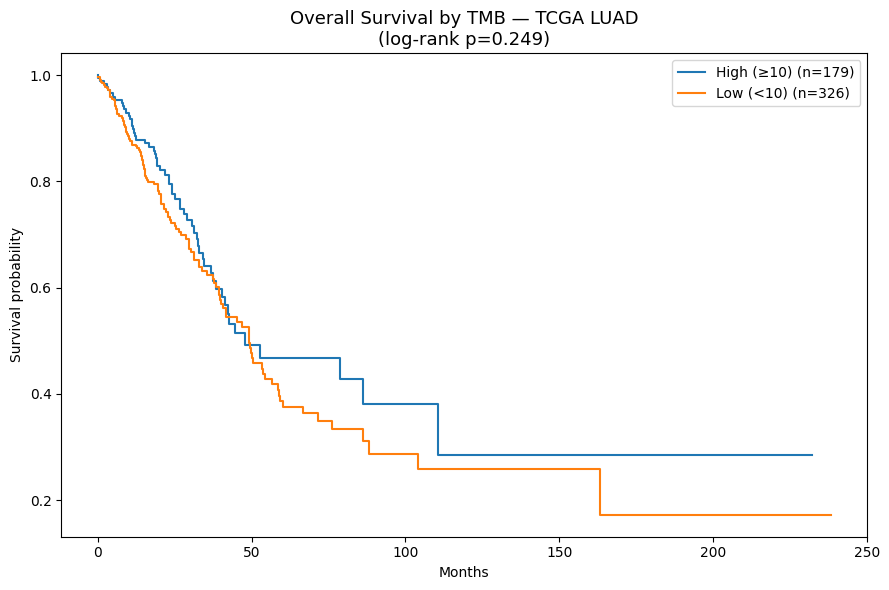

In [7]:
fig, ax = plt.subplots(figsize=(9,6))

for group, data in df.groupby("TMB_GROUP"):
    kmf = KaplanMeierFitter()
    kmf.fit(data["OS_MONTHS"], data["OS_EVENT"], label=f"{group} (n={len(data)})")
    kmf.plot_survival_function(ax=ax, ci_show=False)

from lifelines.statistics import logrank_test
low = df[df["TMB_GROUP"] == "Low (<10)"]
high = df[df["TMB_GROUP"] == "High (≥10)"]
lr = logrank_test(low["OS_MONTHS"], high["OS_MONTHS"],
                  low["OS_EVENT"], high["OS_EVENT"])

ax.set_title(f"Overall Survival by TMB — TCGA LUAD\n(log-rank p={lr.p_value:.3f})", fontsize=13)
ax.set_xlabel("Months")
ax.set_ylabel("Survival probability")
ax.legend()
plt.tight_layout()
plt.savefig("figures/fig3_km_tmb.png", dpi=150)
plt.show()

TMB does not show significant overall prognostic value (log-rank p=0.249), consistent 
with TCGA data predating widespread immunotherapy use. However, a visual separation 
emerges after ~50 months, with TMB-high patients showing better long-term survival — 
suggesting TMB may be more relevant as a predictive biomarker for immunotherapy response 
than as a general prognostic factor. This hypothesis will be revisited in the 
mutation analysis section.

In [8]:
print("MSI stats:")
print(df["MSI_SENSOR_SCORE"].describe())
print("\nMissing:", df["MSI_SENSOR_SCORE"].isna().sum())

MSI stats:
count    504.000000
mean       0.143472
std        0.482977
min        0.000000
25%        0.000000
50%        0.010000
75%        0.100000
max        6.820000
Name: MSI_SENSOR_SCORE, dtype: float64

Missing: 1


In [9]:
print("MSI-High (≥3.5):", (df["MSI_SENSOR_SCORE"] >= 3.5).sum())
print("MSI-Low (<3.5):", (df["MSI_SENSOR_SCORE"] < 3.5).sum())

MSI-High (≥3.5): 3
MSI-Low (<3.5): 501


## 5. Microsatellite Instability (MSI)
MSI-High is a pan-tumor biomarker for immunotherapy response (pembrolizumab FDA-approved). 
In colorectal cancer, MSI-High reaches ~15% of patients. In LUAD, only 3/504 patients 
(0.6%) meet the MSI-High threshold (≥3.5) — consistent with published literature showing 
LUAD is predominantly microsatellite stable. MSI is therefore not a clinically actionable 
stratification factor in this cohort and is not analyzed further.

In [10]:
mutations = pd.read_csv(
    "../data/raw/luad_tcga_pan_can_atlas_2018/data_mutations.txt",
    sep="\t", low_memory=False
)
print("Shape:", mutations.shape)
print("Columns:", mutations.columns.tolist()[:10])
print("\nTop mutated genes:")
print(mutations["Hugo_Symbol"].value_counts().head(15))

Shape: (243229, 114)
Columns: ['Hugo_Symbol', 'Entrez_Gene_Id', 'Center', 'NCBI_Build', 'Chromosome', 'Start_Position', 'End_Position', 'Strand', 'Consequence', 'Variant_Classification']

Top mutated genes:
Hugo_Symbol
TTN       1040
MUC16      617
RYR2       542
CSMD3      522
LRP1B      435
USH2A      404
ZFHX4      375
TP53       343
FLG        298
XIRP2      295
SPTA1      276
FAT3       256
PCDH15     230
CSMD1      224
ZNF536     223
Name: count, dtype: int64


In [11]:
genes_of_interest = ["EGFR", "KRAS", "TP53", "STK11", "KEAP1", "ALK", "ROS1", "BRAF", "MET"]

for gene in genes_of_interest:
    n = (mutations["Hugo_Symbol"] == gene).sum()
    print(f"{gene}: {n} mutations")

EGFR: 93 mutations
KRAS: 186 mutations
TP53: 343 mutations
STK11: 93 mutations
KEAP1: 111 mutations
ALK: 69 mutations
ROS1: 35 mutations
BRAF: 51 mutations
MET: 29 mutations


In [12]:
# Pacientes mutados por gen (uno o más)
mutated_patients = {}
for gene in genes_of_interest:
    mutated = mutations[mutations["Hugo_Symbol"] == gene]["Tumor_Sample_Barcode"].unique()
    # TCGA sample IDs tienen formato TCGA-XX-XXXX-01 — necesitamos match con PATIENT_ID
    # Extraemos los primeros 12 caracteres
    patient_ids = set([s[:12] for s in mutated])
    mutated_patients[gene] = patient_ids
    print(f"{gene}: {len(patient_ids)} patients mutated")

EGFR: 75 patients mutated
KRAS: 168 patients mutated
TP53: 295 patients mutated
STK11: 77 patients mutated
KEAP1: 104 patients mutated
ALK: 48 patients mutated
ROS1: 33 patients mutated
BRAF: 42 patients mutated
MET: 26 patients mutated


## 6. Driver Mutation Analysis
LUAD is characterized by distinct oncogenic driver mutations with therapeutic implications. 
We analyze the most clinically relevant genes: EGFR and KRAS (the two most common drivers), 
TP53 (tumor suppressor), STK11 and KEAP1 (co-mutations associated with poor prognosis), 
and targetable alterations (ALK, ROS1, BRAF, MET).

Mutation status is extracted from somatic variant calls and mapped to patient-level binary 
flags for survival analysis.

In [13]:
# Agregar flags al dataframe clinical
for gene in genes_of_interest:
    df[f"{gene}_MUT"] = df["PATIENT_ID"].isin(mutated_patients[gene]).astype(int)

# Verificar
print("Mutation prevalence in clinical cohort:")
for gene in genes_of_interest:
    n = df[f"{gene}_MUT"].sum()
    pct = n/len(df)*100
    print(f"  {gene}: {n} ({pct:.1f}%)")

Mutation prevalence in clinical cohort:
  EGFR: 70 (13.9%)
  KRAS: 155 (30.7%)
  TP53: 262 (51.9%)
  STK11: 75 (14.9%)
  KEAP1: 96 (19.0%)
  ALK: 39 (7.7%)
  ROS1: 31 (6.1%)
  BRAF: 41 (8.1%)
  MET: 21 (4.2%)


### EGFR and KRAS — The Two Major Drivers
EGFR and KRAS are the most frequent and clinically relevant driver mutations in LUAD. 
EGFR mutations are targetable with tyrosine kinase inhibitors (erlotinib, osimertinib) 
and associated with better prognosis. KRAS mutations (historically undruggable, now 
partially targetable with sotorasib) are more common and generally associated with 
worse outcomes. We expect opposite survival patterns for these two drivers.

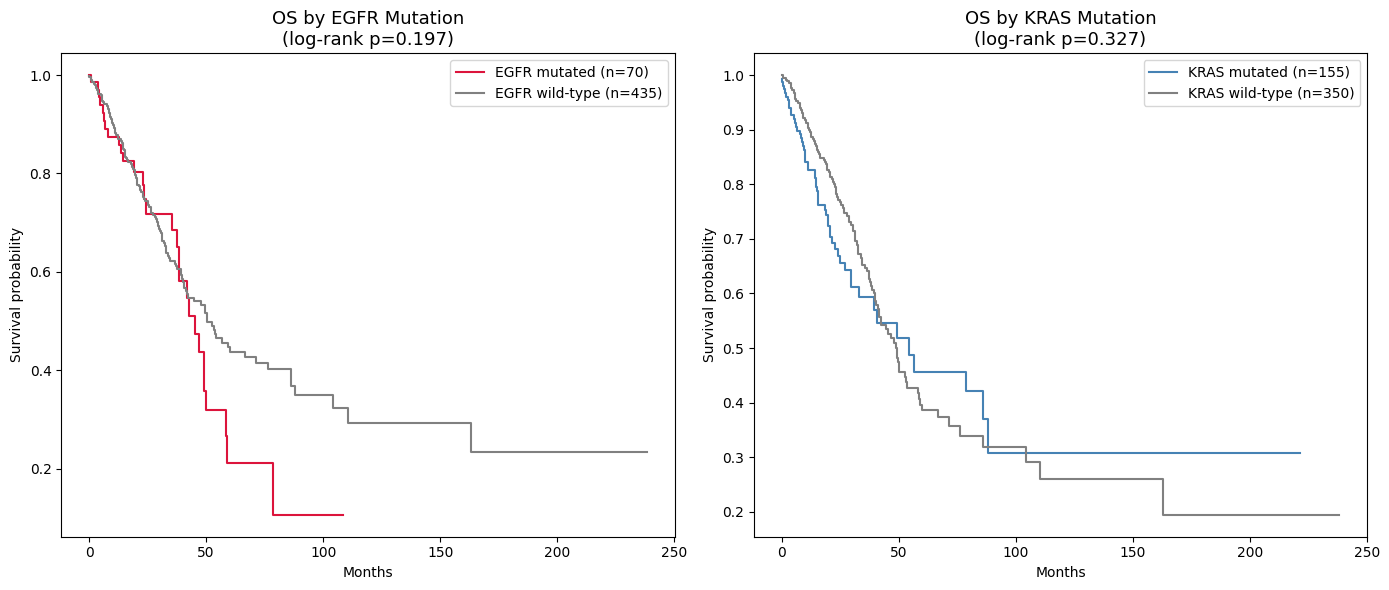

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, gene, color_mut, color_wt in zip(
    axes, 
    ["EGFR", "KRAS"],
    ["crimson", "steelblue"],
    ["gray", "gray"]
):
    for status, label, color in [
        (1, f"{gene} mutated", color_mut),
        (0, f"{gene} wild-type", color_wt)
    ]:
        group = df[df[f"{gene}_MUT"] == status]
        kmf = KaplanMeierFitter()
        kmf.fit(group["OS_MONTHS"], group["OS_EVENT"],
                label=f"{label} (n={len(group)})")
        kmf.plot_survival_function(ax=ax, ci_show=False, color=color)

    # Log-rank
    mut = df[df[f"{gene}_MUT"] == 1]
    wt  = df[df[f"{gene}_MUT"] == 0]
    lr = logrank_test(mut["OS_MONTHS"], wt["OS_MONTHS"],
                      mut["OS_EVENT"], wt["OS_EVENT"])

    ax.set_title(f"OS by {gene} Mutation\n(log-rank p={lr.p_value:.3f})", fontsize=13)
    ax.set_xlabel("Months")
    ax.set_ylabel("Survival probability")
    ax.legend()

plt.tight_layout()
plt.savefig("figures/fig4_km_egfr_kras.png", dpi=150)
plt.show()

EGFR-mutated patients show a trend toward worse overall survival, with no patients 
surviving beyond 120 months compared to long-term survivors in the wild-type group. 
However, this does not reach statistical significance (p=0.197), likely due to limited 
power with only 70 EGFR-mutated patients. This finding is counterintuitive given that 
EGFR mutations are targetable — but may reflect that TCGA patients predate widespread 
use of third-generation TKIs (osimertinib), and that EGFR-mutated tumors may have 
higher recurrence rates despite initial treatment response.

KRAS mutation shows no clear prognostic effect (p=0.327), consistent with its role 
as a driver rather than a pure prognostic biomarker in the pre-sotorasib era.
The KRAS survival curves cross multiple times, indicating no consistent directional 
effect over time and suggesting heterogeneity within the KRAS-mutated group. 
KRAS comprises multiple subtypes (G12C, G12V, G12D) with distinct biology — 
this will be explored in the mutation co-occurrence analysis.    